# Modeling Logistic Growth with SINDy

Consider the following generalized growth equation (needs a better name):

$$
\dot x = r_0 x(1-\rho_1 x - \rho_2 x^2 - \ldots - \rho_n x^n)
$$

With $(\rho_n)_{n \geq 1}$ a sequence of non-negative real numbers.

Our goal is to:
1) Create some sample data points of the model
2) Train a UDE on the data points
3) Apply SINDy on extra data points created from the trained UDE

In [1]:
from torch import nn
import torch 
import pysindy as ps
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt 
from torchdiffeq import odeint

[0.    0.25  0.1   0.001 1.   ]


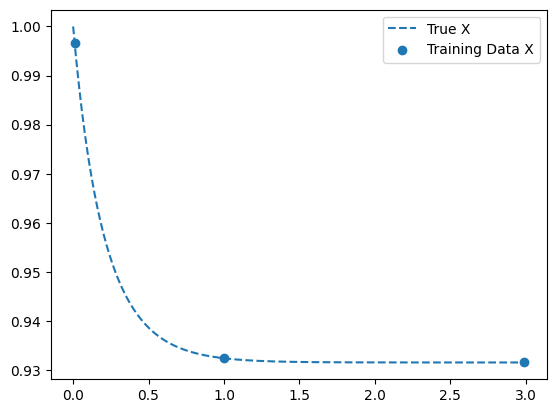

In [2]:
# Step 1: generate model and get a sampling of its data

k = 6
rho0 = 1
rho = np.array(
    [0, 0.25, 0.1, 0.001, 1]
)

print(rho)

def generalised_growth(t, data, k, rho):
    x = data[0]
    powers = np.arange(1, k)
    x_pow = np.power(x, powers)

    return np.array(
        [rho0 * x * (1 - np.dot(x_pow, rho)) ]
    )


sol = solve_ivp(generalised_growth, t_span = [0, 3], args= (k, rho), y0 = [1], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,3, 0.01))
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", label="True X")


T_train = T[[1,100,-1]]
X_train = X[[1,100, -1]]
plt.scatter(T_train, X_train, label="Training Data X")


plt.legend()

plt.show()

In [3]:
model_old = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=ps.SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=10000)
)
model_old.fit(X_train, T_train, feature_names=['x'])


c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


,optimizer,SR3(initial_g...ax_iter=10000)
,feature_library,PolynomialLib...de_bias=False)
,differentiation_method,FiniteDifference()
,degree,6
,include_interaction,True
,interaction_only,False
,include_bias,False
,order,'C'
,reg_weight_lam,0.005
,regularizer,'L0'
,relax_coeff_nu,1.0


In [4]:
model_old.print()

(x)' =  0.655 x + -0.295 x^2 + -0.248 x^3 + -0.204 x^4


In [5]:
# Step 2. Create UDE of type x NN(x) and make it learn...

class ude_generalised_growth(nn.Module):
    def __init__(self, rho0):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 10),
            nn.Tanh(),
            nn.Linear(10, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 10),
            nn.Tanh(),
            nn.Linear(10, 1)
        ) 

    def forward(self, t, x):
        return x * (self.net(x))

In [6]:
my_growth = ude_generalised_growth(rho0)

In [77]:
from tqdm import tqdm 

lr = 0.005
optimizer = torch.optim.Adam(my_growth.parameters(), lr=lr)

n_epochs = 500
SKIP = 4

rtol = 1e-7

t_train_torch = torch.tensor(T_train)

for EPOCH in (range(n_epochs)):
    optimizer.zero_grad()
    
    # forward solution
    x_pred = odeint(my_growth, 
                    torch.tensor([1.], requires_grad=True),
                    t_train_torch,
                    )
    
    # Compute loss at training points
    loss = torch.tensor(0.0)
    for i, (t, x_true) in enumerate(zip(T_train, X_train)):
        loss = loss + (x_pred[i] - x_true) ** 2
    
    loss = loss / len(T_train)
    
    # Backpropagate
    loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        x_check = odeint(my_growth, 
                    torch.tensor([1.], requires_grad=True),
                    t_train_torch)
        
        loss_check = torch.tensor(0.0)
        for i, (t, x_true) in enumerate(zip(T_train, X_train)):
            loss_check = loss_check + (x_check[i] - x_true) ** 2

        loss_check = loss_check / len(T_train)
        print(f"Epoch {EPOCH}: MSE Loss = {loss_check.item()}")


C:\Users\ACER\AppData\Local\Temp\ipykernel_24424\564900629.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_train_torch = torch.tensor(T_train)


Epoch 0: MSE Loss = 2.378232056798879e-05
Epoch 1: MSE Loss = 0.00042296203901059926
Epoch 2: MSE Loss = 1.855388291005511e-05
Epoch 3: MSE Loss = 0.00017667165957391262
Epoch 4: MSE Loss = 0.00024041510187089443
Epoch 5: MSE Loss = 6.352893979055807e-05
Epoch 6: MSE Loss = 1.2858402442361694e-05
Epoch 7: MSE Loss = 0.00011850040755234659
Epoch 8: MSE Loss = 0.00014208890206646174
Epoch 9: MSE Loss = 5.693005005014129e-05
Epoch 10: MSE Loss = 3.917886260751402e-06
Epoch 11: MSE Loss = 4.276899198885076e-05
Epoch 12: MSE Loss = 8.853559847921133e-05
Epoch 13: MSE Loss = 6.637020851485431e-05
Epoch 14: MSE Loss = 1.6274383597192355e-05
Epoch 15: MSE Loss = 7.302481662918581e-06
Epoch 16: MSE Loss = 3.9067654142854735e-05
Epoch 17: MSE Loss = 5.582509038504213e-05
Epoch 18: MSE Loss = 3.4001845051534474e-05
Epoch 19: MSE Loss = 7.005360657785786e-06
Epoch 20: MSE Loss = 9.328537089459132e-06
Epoch 21: MSE Loss = 2.991483052028343e-05
Epoch 22: MSE Loss = 3.432039011386223e-05
Epoch 23: MS

In [98]:
torch.save(my_growth.state_dict(), "./models_weights/growth_ude.dm")

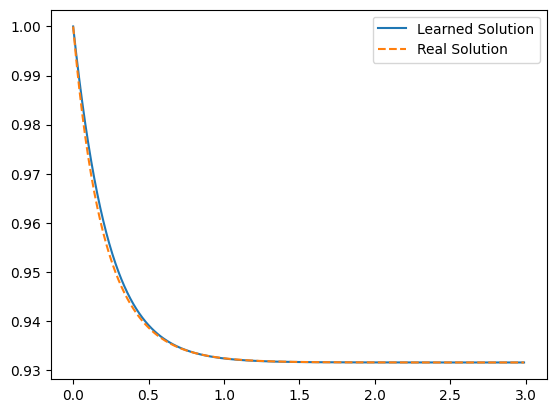

In [99]:
x_pred = odeint(my_growth, 
                torch.tensor([1.], requires_grad=True),
                T_torch := torch.arange(0, 3, 0.01)
                )

plt.plot(T_torch, x_pred.detach().numpy(), label="Learned Solution")

sol = solve_ivp(generalised_growth, t_span = [0, 3], args= (k, rho), y0 = [1], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,3, 0.01))
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", label="Real Solution")

plt.legend()


c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


,optimizer,SR3(initial_g...x_iter=100000)
,feature_library,PolynomialLib...de_bias=False)
,differentiation_method,FiniteDifference(axis=-2)
,degree,6
,include_interaction,True
,interaction_only,False
,include_bias,False
,order,'C'
,reg_weight_lam,0.005
,regularizer,'L0'
,relax_coeff_nu,1.0


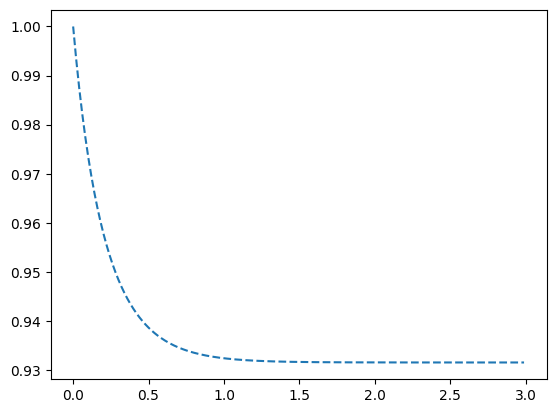

In [ ]:
# Now... train SINDy with the new derivatives

# recover data
sol = solve_ivp(generalised_growth, t_span = [0, 3], args= (k, rho), y0 = [1], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,3, 0.01))
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", label="True X")


T_train = torch.tensor(T[[1,100, -1]])
X_train = torch.tensor(X[[1,100, -1]], dtype=torch.float32)

X_dot = torch.zeros(T_train.shape[0])

for i, (t, x) in enumerate(zip(T_train, X_train)):
    X_dot[i] = my_growth(t, torch.tensor([x], dtype=torch.float32))


model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=ps.SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=100000)
)

model.fit(X_train.detach().numpy(), T_train.detach().numpy(), feature_names=['x'], x_dot=X_dot.detach().numpy())

c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


,optimizer,SR3(initial_g...x_iter=100000)
,feature_library,PolynomialLib...de_bias=False)
,differentiation_method,FiniteDifference(axis=-2)
,degree,6
,include_interaction,True
,interaction_only,False
,include_bias,False
,order,'C'
,reg_weight_lam,0.005
,regularizer,'L0'
,relax_coeff_nu,1.0


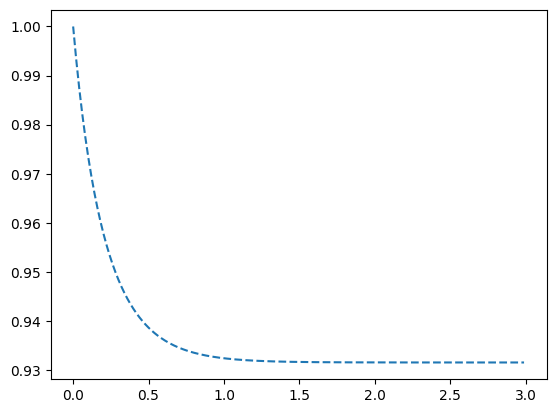

In [134]:
# Now... train SINDy with the new derivatives

# recover data
sol = solve_ivp(generalised_growth, t_span = [0, 3], args= (k, rho), y0 = [1], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,3, 0.01))
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", label="True X")


# we use lots of data instead
T_train = T
X_train = X

X_dot = torch.zeros(T_train.shape[0])

for i, (t, x) in enumerate(zip(T_train, X_train)):
    X_dot[i] = my_growth(t, torch.tensor([x], dtype=torch.float32))


model_lots = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=ps.SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=100000),
)

model_lots.fit(X_train, T_train, feature_names=['x'], x_dot=X_dot.detach().numpy())

In [135]:
model.coefficients()

array([[ 0.95561354, -0.        , -0.20732418, -0.28012395, -0.34766765,
        -0.41035076]])

In [136]:
model_lots.coefficients()

array([[ 1.9921077 , -0.        , -2.29803756,  0.        ,  0.        ,
         0.        ]])

In [ ]:
#     [1, 0, 0.25, 0.1, 0.001, 1]

In [138]:
def poly_sindy(x, deg, model):
    p = np.zeros(deg)
    p[1:] = model.coefficients()

    p = p[::-1]

    return np.polyval(p, x)

def poly_real(x, deg):
    p = np.zeros(deg)

    p[1] = 1

    p[2:] = -rho0 * rho.reshape(deg-2)

    p = p[::-1]

    return np.polyval(p, x)

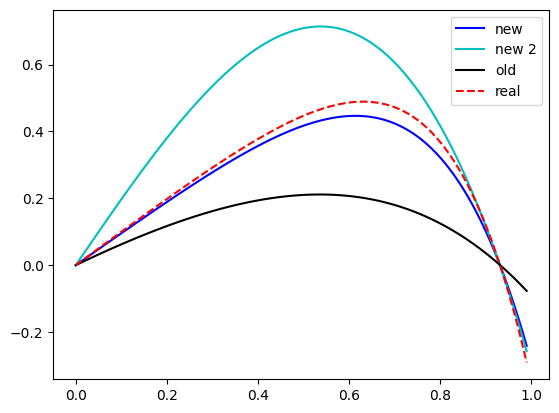

In [ ]:
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model), "b", label="new")
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model_lots), "c", label="new 2")
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model_old), "k", label="old")
plt.plot(np.arange(0, 1, 0.01), poly_real(np.arange(0, 1, 0.01), k+1), "r--", label="real")

plt.legend()

In [140]:
from scipy.integrate import quad

In [141]:
def poly_diff1(x):
    return (poly_sindy(x, k+1, model)-poly_real(x, k+1))**2

def poly_diff2(x):
    return (poly_sindy(x, k+1, model_old)-poly_real(x, k+1))**2

print("L2 Erorr in [0,1] before data augmentation with UDEs:\t", quad(poly_diff2, 0, 1),"\nL2 Error after:\t",
quad(poly_diff1, 0, 1))

L2 Erorr in [0,1] before data augmentation with UDEs:	 (0.03593026242180781, 3.9890604621515067e-16) 
L2 Error after:	 (0.0008852684339791307, 9.828453983774862e-18)
